## This will house the visuals for our models and make it easy to compare them

In [128]:
# import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
# from sklearn.inspection import permutation_importance
# import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, confusion_matrix, classification_report, r2_score,mean_squared_error

## From stored varibales in other files import the classsifaction matricies

In [129]:
%store -r dt_cr rf_cr gbc_cr knn_cr mlp_cr mlp_balanced_cr AutoML_cr

reports = {
    "DT":dt_cr,
    "RF":rf_cr,
    "GBC":gbc_cr,
    "knn": knn_cr,
    "mlp":mlp_cr,
    "mlp_balanced":mlp_balanced_cr,
    "AutoML":AutoML_cr,
    # "TabPFN":TabPFN_cr,

}

## Create Some functions to extract the needed metrics

In [130]:
#from classification report
f1_scores = {}
recall = {}
support = {}
precision = {}
accuracy = {}
for i,j in reports.items():
    print(i,j)

def fill_data():
    for n_model, model_report in reports.items():
        f1_scores[n_model] = model_report['1']['f1-score']
        recall[n_model] =model_report['1']['recall']
        support[n_model] = model_report['1']['support']
        precision[n_model] =model_report['1']['precision']
        accuracy[n_model] =model_report['accuracy']

    return {
    "F1_Scores":f1_scores,
    "recall":recall,
    "support":support,
    "precision":precision,
    "accuracy":accuracy,
}


DT {'0': {'precision': 0.997709049255441, 'recall': 0.9285714285714286, 'f1-score': 0.9618995030369961, 'support': 938.0}, '1': {'precision': 0.3163265306122449, 'recall': 0.9393939393939394, 'f1-score': 0.4732824427480916, 'support': 33.0}, 'accuracy': 0.9289392378990731, 'macro avg': {'precision': 0.657017789933843, 'recall': 0.933982683982684, 'f1-score': 0.7175909728925438, 'support': 971.0}, 'weighted avg': {'precision': 0.9745518678803377, 'recall': 0.9289392378990731, 'f1-score': 0.9452935679293403, 'support': 971.0}}
RF {'0': {'precision': 0.9945828819068255, 'recall': 0.9786780383795309, 'f1-score': 0.9865663621708759, 'support': 938.0}, '1': {'precision': 0.5833333333333334, 'recall': 0.8484848484848485, 'f1-score': 0.691358024691358, 'support': 33.0}, 'accuracy': 0.9742533470648815, 'macro avg': {'precision': 0.7889581076200795, 'recall': 0.9135814434321897, 'f1-score': 0.8389621934311169, 'support': 971.0}, 'weighted avg': {'precision': 0.9806063267029891, 'recall': 0.97425

### Now we plot the metrics so as to compare the models with each other

In [131]:
def main():
    for m_name,metric in fill_data().items():
        nnames = list(metric.keys())
        values = list(metric.values())
        print(m_name)
        print(metric)

        plt.figure()
        plt.bar(nnames, values)

        plt.xlabel("Model")
        plt.ylabel("Value")
        plt.title(f"{m_name}")

        plt.show()

F1_Scores
{'DT': 0.4732824427480916, 'RF': 0.691358024691358, 'GBC': 0.5084745762711864, 'knn': 0.6129032258064516, 'mlp': 0.8611111111111112, 'mlp_balanced': 0.8780487804878049, 'AutoML': 0.9620253164556962}


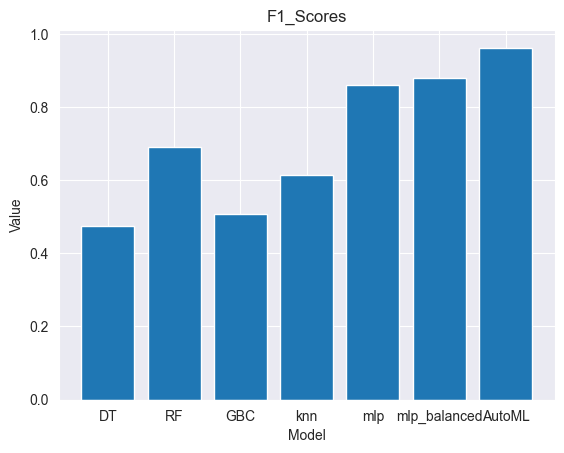

recall
{'DT': 0.9393939393939394, 'RF': 0.8484848484848485, 'GBC': 0.39473684210526316, 'knn': 0.5, 'mlp': 0.8157894736842105, 'mlp_balanced': 0.9473684210526315, 'AutoML': 1.0}


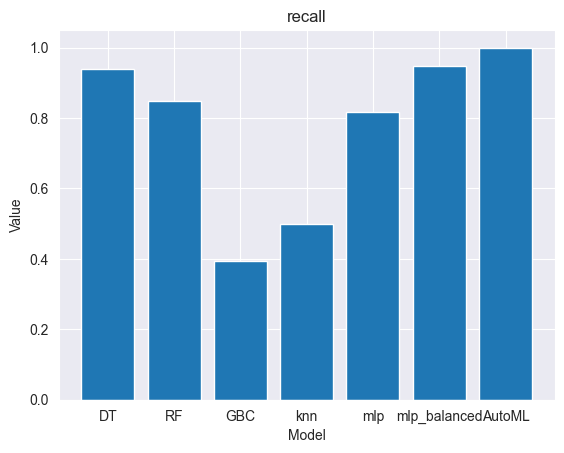

support
{'DT': 33.0, 'RF': 33.0, 'GBC': 38.0, 'knn': 38.0, 'mlp': 38.0, 'mlp_balanced': 38.0, 'AutoML': 38.0}


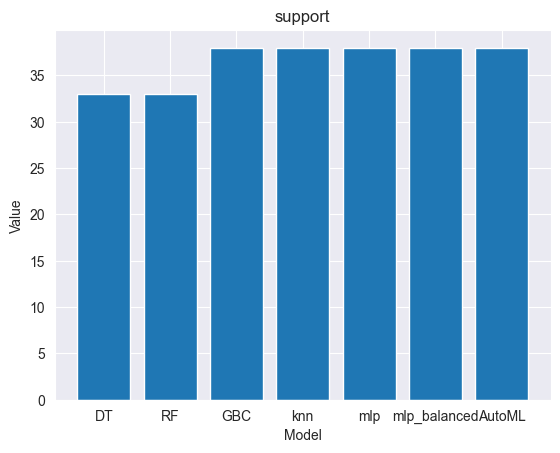

precision
{'DT': 0.3163265306122449, 'RF': 0.5833333333333334, 'GBC': 0.7142857142857143, 'knn': 0.7916666666666666, 'mlp': 0.9117647058823529, 'mlp_balanced': 0.8181818181818182, 'AutoML': 0.926829268292683}


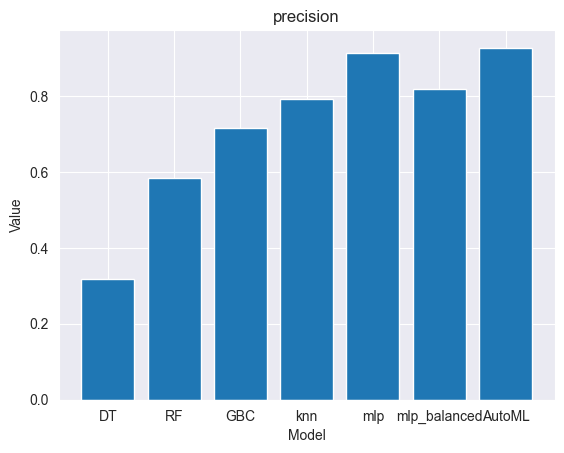

accuracy
{'DT': 0.9289392378990731, 'RF': 0.9742533470648815, 'GBC': 0.9701338825952626, 'knn': 0.9752832131822863, 'mlp': 0.9897013388259527, 'mlp_balanced': 0.9897013388259527, 'AutoML': 0.9969104016477858}


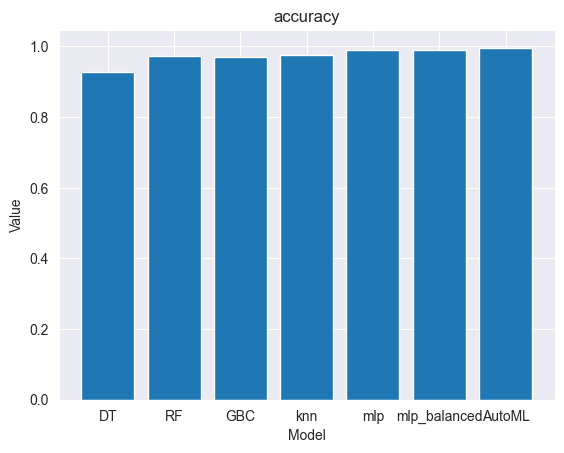

In [132]:
if __name__ == "__main__":
    main()